# Кейс 3. Когорты, повторные покупки и реактивация

**Вопросы:**
1. Какая доля регистраций доходит до первой покупки и как это зависит от окна подсчёта.
2. Сколько покупателей возвращаются в следующие месяцы.
3. Сколько покупателей реактивируется после паузы 180+ дней и почему короткая история в хранилище ломает эту метрику.

**Главное правило:** покупка = уникальный день заказа пользователя. Одна покупка на маркетплейсе приезжает несколькими посылками, у каждой свой order_id. Если считать покупки по order_id, новичок с тремя посылками в первый день выглядит как повторный покупатель.

In [1]:
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from src import pf

pf.setup_style()
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
con = pf.connect()
q = pf.Q(con, "queries.sql")
con.execute(q.queries["purchase_days_view"])

## 1. Посылки и покупки

In [2]:
pp = q("parcels_per_purchase")
avg_parcels = (pp["parcels"] * pp["purchases"]).sum() / pp["purchases"].sum()
print(f"В среднем {avg_parcels:.2f} посылки на одну покупку, покупок с 2+ посылками: {pp.loc[pp['parcels'] >= 2, 'share'].sum():.0%}")
pp

В среднем 1.88 посылки на одну покупку, покупок с 2+ посылками: 58%


,parcels,purchases,share
0,1,15655,0.417
1,2,13669,0.364
2,3,5947,0.158
3,4,1763,0.047
4,5,410,0.011
5,6,87,0.002


## 2. Конверсия в первую покупку: окно решает

Три окна для одной и той же когорты:
- **месяц регистрации**: покупка в том же календарном месяце. Регистрация 30-го числа почти не имеет шансов, регистрация 1-го имеет месяц;
- **30 дней** от регистрации: одинаковое окно для всех;
- **за всё время** до даты выгрузки: у старых когорт было больше времени, поэтому сравнивать когорты по этой метрике нельзя.

In [3]:
cc = q("cohort_conversion")
cc["cohort"] = cc["cohort_month"].dt.strftime("%Y-%m")
cc[["cohort", "regs", "cr_same_month", "cr_d30", "cr_lifetime", "days_observed"]]

,cohort,regs,cr_same_month,cr_d30,cr_lifetime,days_observed
0,2025-03,2281,0.121,0.149,0.182,562
1,2025-04,2199,0.124,0.151,0.181,531
2,2025-05,2265,0.117,0.145,0.177,501
3,2025-06,2210,0.129,0.158,0.191,470
4,2025-07,2348,0.114,0.143,0.176,440
5,2025-08,2478,0.126,0.152,0.184,409
6,2025-09,2536,0.119,0.154,0.190,378
7,2025-10,3079,0.121,0.148,0.181,348
8,2025-11,3002,0.129,0.158,0.190,317
9,2025-12,3399,0.116,0.145,0.183,287


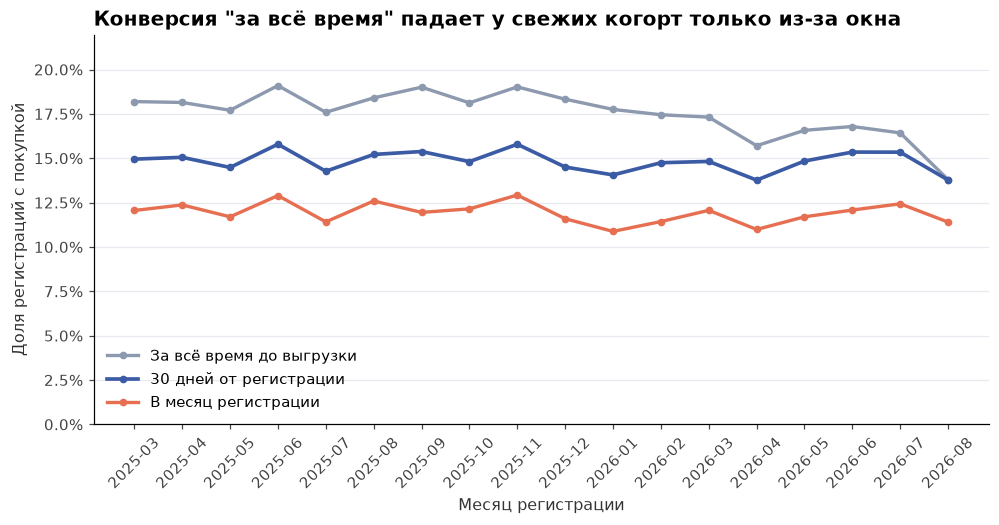

In [4]:
fig, ax = plt.subplots(figsize=(10.5, 4.6))
ax.plot(cc["cohort"], cc["cr_lifetime"], color=pf.COLORS["muted"], lw=2.2, marker="o", ms=4, label="За всё время до выгрузки")
ax.plot(cc["cohort"], cc["cr_d30"], color=pf.COLORS["main"], lw=2.4, marker="o", ms=4, label="30 дней от регистрации")
ax.plot(cc["cohort"], cc["cr_same_month"], color=pf.COLORS["accent"], lw=2.2, marker="o", ms=4, label="В месяц регистрации")
pf.pct_axis(ax)
ax.set_ylim(0, cc["cr_lifetime"].max() * 1.15)
ax.set_xlabel("Месяц регистрации")
ax.set_ylabel("Доля регистраций с покупкой")
ax.set_title("Конверсия \"за всё время\" падает у свежих когорт только из-за окна")
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="lower left")
pf.save(fig, "01_conversion_windows")
plt.show()

In [5]:
mature = cc[cc["cohort_month"] < "2025-09-01"]
cr_life_mature = mature["buyers_lifetime"].sum() / mature["regs"].sum()
cr_same_all = cc["buyers_same_month"].sum() / cc["regs"].sum()
cr_d30_all = cc["buyers_d30"].sum() / cc["regs"].sum()
last = cc.iloc[-1]
print(f"Все когорты 03.2025-08.2026: в месяц регистрации {cr_same_all:.1%}, за 30 дней {cr_d30_all:.1%}")
print(f"Когорты 03.2025-08.2025 (12+ мес. истории), за всё время: {cr_life_mature:.1%}")
print(f"Когорта {last['cohort']}: за всё время {last['cr_lifetime']:.1%} при {last['days_observed']} днях наблюдения")

Все когорты 03.2025-08.2026: в месяц регистрации 11.9%, за 30 дней 14.8%
Когорты 03.2025-08.2025 (12+ мес. истории), за всё время: 18.2%
Когорта 2026-08: за всё время 13.8% при 44 днях наблюдения


## 3. Когортная тепловая карта

Доля когорты, у которой была покупка в месяце N после регистрации. M0 = месяц регистрации. Сентябрь 2026 неполный и в карту не входит.

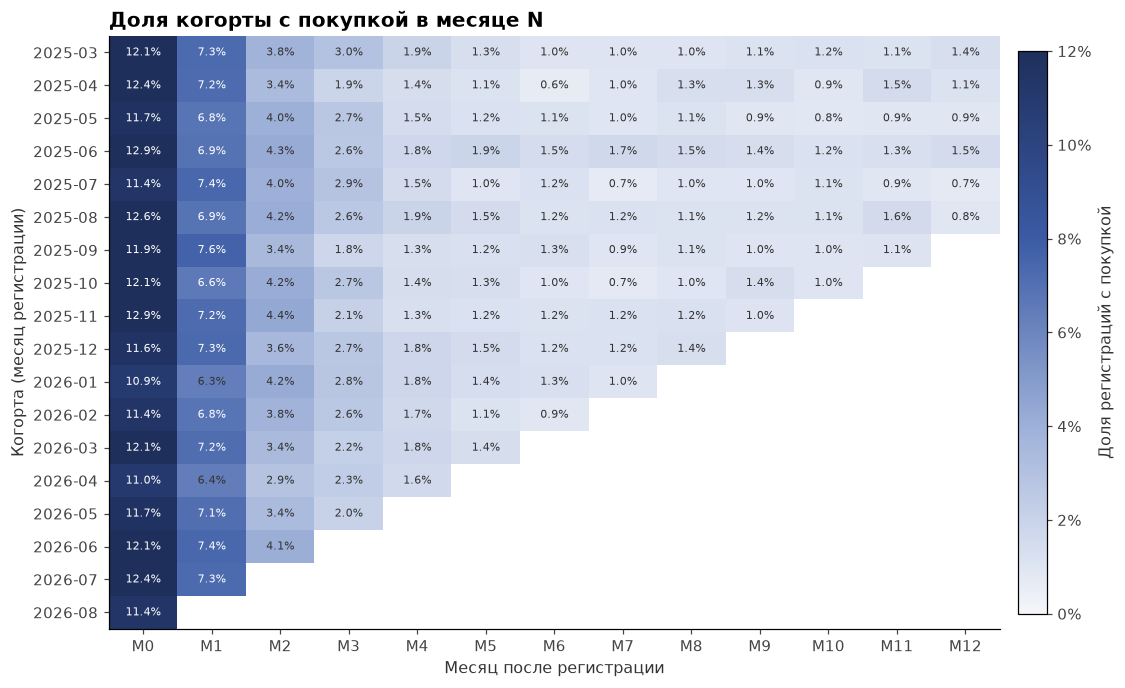

In [6]:
rm = q("retention_matrix")
heat = rm.pivot(index="cohort_month", columns="month_n", values="active_share")
heat.index = heat.index.strftime("%Y-%m")
fig, ax = plt.subplots(figsize=(11, 7))
cmap = mcolors.LinearSegmentedColormap.from_list("pf", ["#F4F6FA", "#9DB0D8", "#3B5BA5", "#1E2F5C"])
im = ax.imshow(heat.values, cmap=cmap, aspect="auto", vmin=0, vmax=0.12)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.1%}", ha="center", va="center", fontsize=7.5, color="white" if v > 0.065 else "#333333")
ax.set_xticks(range(heat.shape[1]), [f"M{m}" for m in heat.columns])
ax.set_yticks(range(heat.shape[0]), heat.index)
ax.set_xlabel("Месяц после регистрации")
ax.set_ylabel("Когорта (месяц регистрации)")
ax.set_title("Доля когорты с покупкой в месяце N")
ax.grid(False)
cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, format=pf.mtick.PercentFormatter(1.0, decimals=0))
cb.set_label("Доля регистраций с покупкой")
pf.save(fig, "02_cohort_heatmap")
plt.show()

In [7]:
m0 = heat[0].mean()
m1 = heat[1].mean()
m3 = heat[3].mean()
m6 = heat[6].mean()
m12 = heat[12].dropna().mean()
print(f"Средняя по когортам доля активных: M0 {m0:.1%}, M1 {m1:.1%}, M3 {m3:.1%}, M6 {m6:.1%}, M12 {m12:.1%}")

Средняя по когортам доля активных: M0 11.9%, M1 7.1%, M3 2.5%, M6 1.1%, M12 1.1%


## 4. Повторные покупатели: по посылкам и по дням

In [8]:
rb = q("repeat_buyers_monthly")
rb["share_parcels"] = rb["repeat_by_parcels"] / rb["buyers"]
rb["share_days"] = rb["repeat_by_days"] / rb["buyers"]
rb["month_s"] = rb["month"].dt.strftime("%Y-%m")
rb[["month_s", "buyers", "repeat_by_parcels", "repeat_by_days", "share_parcels", "share_days"]]

,month_s,buyers,repeat_by_parcels,repeat_by_days,share_parcels,share_days
0,2025-03,823,683,491,0.830,0.597
1,2025-04,868,719,502,0.828,0.578
2,2025-05,853,698,526,0.818,0.617
3,2025-06,873,718,511,0.822,0.585
4,2025-07,867,726,529,0.837,0.610
5,2025-08,964,818,572,0.849,0.593
6,2025-09,954,798,576,0.836,0.604
7,2025-10,1069,891,626,0.833,0.586
8,2025-11,1128,935,661,0.829,0.586
9,2025-12,1158,985,676,0.851,0.584


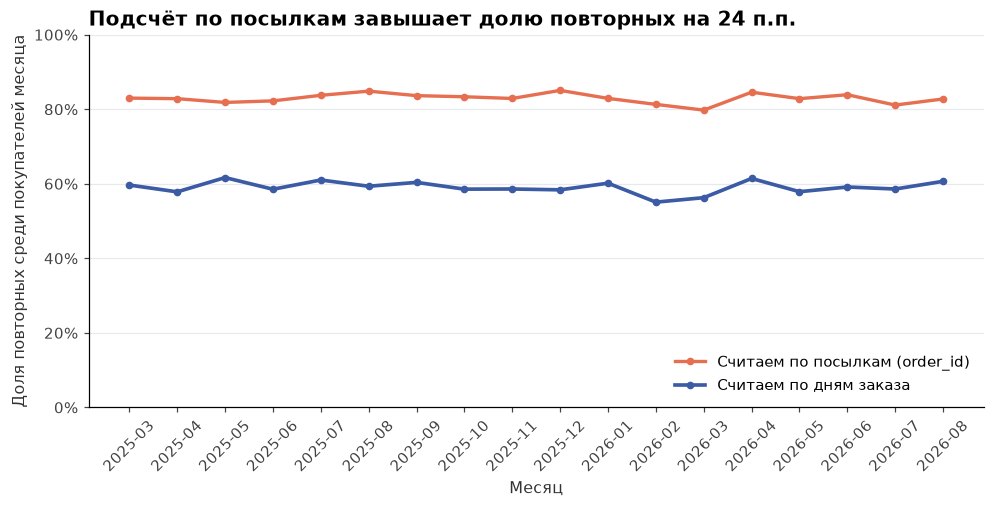

In [9]:
fig, ax = plt.subplots(figsize=(10.5, 4.4))
ax.plot(rb["month_s"], rb["share_parcels"], color=pf.COLORS["accent"], lw=2.2, marker="o", ms=4, label="Считаем по посылкам (order_id)")
ax.plot(rb["month_s"], rb["share_days"], color=pf.COLORS["main"], lw=2.4, marker="o", ms=4, label="Считаем по дням заказа")
pf.pct_axis(ax)
ax.set_ylim(0, 1)
ax.set_ylabel("Доля повторных среди покупателей месяца")
ax.set_xlabel("Месяц")
gap_pp = (rb["share_parcels"] - rb["share_days"]).mean()
ax.set_title(f"Подсчёт по посылкам завышает долю повторных на {gap_pp * 100:.0f} п.п.")
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="lower right")
pf.save(fig, "03_repeat_parcels_vs_days")
plt.show()

## 5. Реактивация после 180+ дней

Реактивированный покупатель месяца: у него есть покупка в этом месяце, а предыдущая была 180 и более дней назад.

Ловушка: если в хранилище заказы лежат только с какой-то даты (например, после миграции с 01.01.2025), то пользователь, который покупал в 2024 году и вернулся в 2025, выглядит новым покупателем. Реактивацию недосчитываем до тех пор, пока глубина истории не превысит самую длинную паузу.

In [10]:
full = q("reactivation_full").set_index("month")
short = q("reactivation_short_history").set_index("month")
cmp_ = pd.DataFrame({
    "buyers": full["buyers"],
    "reactivated_full": full["reactivated"],
    "reactivated_short": short["reactivated"],
    "new_full": full["new_buyers"],
    "new_short": short["new_buyers"],
})
cmp_["react_share_full"] = cmp_["reactivated_full"] / cmp_["buyers"]
cmp_["react_share_short"] = cmp_["reactivated_short"] / cmp_["buyers"]
cmp_["missed_share"] = 1 - cmp_["reactivated_short"] / cmp_["reactivated_full"]
cmp_.index = cmp_.index.strftime("%Y-%m")
cmp_

,buyers,reactivated_full,reactivated_short,new_full,new_short,react_share_full,react_share_short,missed_share
month,,,,,,,,
2025-01,726,68,0,374,726,0.094,0.000,1.000
2025-02,711,64,0,334,470,0.090,0.000,1.000
2025-03,823,78,0,406,513,0.095,0.000,1.000
2025-04,868,70,0,422,504,0.081,0.000,1.000
2025-05,853,84,0,395,486,0.098,0.000,1.000
2025-06,873,90,0,433,526,0.103,0.000,1.000
2025-07,867,97,7,402,492,0.112,0.008,0.928
2025-08,964,114,23,463,554,0.118,0.024,0.798
2025-09,954,106,32,444,518,0.111,0.034,0.698


In [11]:
gaps = q("dormancy_gaps")["gap"]
p95 = gaps.quantile(0.95)
print(f"Паузы 180+ дней: медиана {gaps.median():.0f} дней, 95-й перцентиль {p95:.0f}, максимум {gaps.max():.0f}")

Паузы 180+ дней: медиана 300 дней, 95-й перцентиль 433, максимум 711


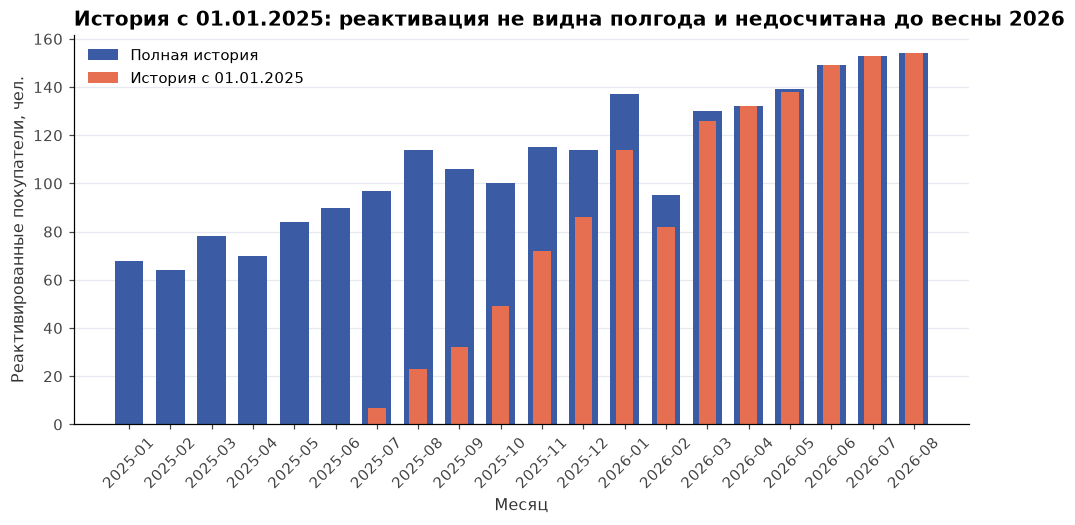

In [12]:
fig, ax = plt.subplots(figsize=(10.5, 4.6))
x = np.arange(len(cmp_))
ax.bar(x, cmp_["reactivated_full"], color=pf.COLORS["main"], width=0.7, label="Полная история")
ax.bar(x, cmp_["reactivated_short"], color=pf.COLORS["accent"], width=0.42, label="История с 01.01.2025")
ax.set_xticks(x, cmp_.index, rotation=45)
ax.set_ylabel("Реактивированные покупатели, чел.")
ax.set_xlabel("Месяц")
ax.set_title("История с 01.01.2025: реактивация не видна полгода и недосчитана до весны 2026")
ax.legend(loc="upper left")
pf.save(fig, "04_reactivation_history_depth")
plt.show()

In [13]:
h1 = cmp_.loc["2025-01":"2025-06"]
h2 = cmp_.loc["2025-07":"2025-12"]
h3 = cmp_.loc["2026-01":"2026-08"]
miss_h1 = 1 - h1["reactivated_short"].sum() / h1["reactivated_full"].sum()
miss_h2 = 1 - h2["reactivated_short"].sum() / h2["reactivated_full"].sum()
miss_h3 = 1 - h3["reactivated_short"].sum() / h3["reactivated_full"].sum()
react_share_2026 = h3["reactivated_full"].sum() / h3["buyers"].sum()
print(f"Недосчёт реактивации: 01-06.2025 {miss_h1:.0%}, 07-12.2025 {miss_h2:.0%}, 01-08.2026 {miss_h3:.0%}")
print(f"Доля реактивированных среди покупателей месяца в 2026: {react_share_2026:.1%}")
extra_new = (h1["new_short"].sum() / h1["new_full"].sum()) - 1
print(f"Новых покупателей в первом полугодии 2025 с короткой историей больше на {extra_new:.0%}")

Недосчёт реактивации: 01-06.2025 100%, 07-12.2025 58%, 01-08.2026 4%
Доля реактивированных среди покупателей месяца в 2026: 9.8%
Новых покупателей в первом полугодии 2025 с короткой историей больше на 36%


## 6. Ключевые числа

In [14]:
res = {
    "avg_parcels_per_purchase": avg_parcels,
    "share_purchases_multi_parcel": pp.loc[pp["parcels"] >= 2, "share"].sum(),
    "cr_same_month_all": cr_same_all,
    "cr_d30_all": cr_d30_all,
    "cr_lifetime_mature": cr_life_mature,
    "last_cohort": last["cohort"],
    "last_cohort_cr_lifetime": last["cr_lifetime"],
    "m0": m0, "m1": m1, "m3": m3, "m6": m6, "m12": m12,
    "repeat_share_parcels_avg": rb["share_parcels"].mean(),
    "repeat_share_days_avg": rb["share_days"].mean(),
    "repeat_gap_pp": gap_pp * 100,
    "gap_median": gaps.median(),
    "gap_p95": p95,
    "react_missed_h1_2025": miss_h1,
    "react_missed_h2_2025": miss_h2,
    "react_missed_2026": miss_h3,
    "react_share_2026": react_share_2026,
    "new_buyers_overstated_h1_2025": extra_new,
}
pf.save_results(res)
pd.Series(res)

avg_parcels_per_purchase           1.877
share_purchases_multi_parcel       0.583
cr_same_month_all                  0.119
cr_d30_all                         0.148
cr_lifetime_mature                 0.182
last_cohort                      2026-08
last_cohort_cr_lifetime            0.138
m0                                 0.119
m1                                 0.071
m3                                 0.025
m6                                 0.011
m12                                0.011
repeat_share_parcels_avg           0.829
repeat_share_days_avg              0.591
repeat_gap_pp                     23.858
gap_median                       300.000
gap_p95                          433.000
react_missed_h1_2025               1.000
react_missed_h2_2025               0.584
react_missed_2026                  0.038
react_share_2026                   0.098
new_buyers_overstated_h1_2025      0.364
dtype: object